# DNN Training (PyTorch)

<div style="text-align: justify">

The following notebook is dedicated to supervised machine learning training for the <b>Tau Supersymmetry</b> search analysis. A deep neural network classifier is trained using <b>PyTorch</b> on the rectangular MC DataFrame produced by the feature engineering pipeline. Input features are normalised with a <b>MinMaxScaler</b> (fit on the training split only) and the model is trained in mini-batches with optional <b>Automatic Mixed Precision (AMP)</b>. Two split strategies are supported: a single stratified train/test split and stratified K-fold cross-validation.

</div>

## Pipeline Summary

| Step | Module | Description |
|------|--------|-------------|
| Config | `hydra.compose` | Load analysis and model configuration |
| MLflow | `mlflow` | Start run and log hyperparameters |
| Load | `io.load_dataframe` | Read mc.parquet from feature engineering output |
| Labels | — | Derive ordered class names from `eventOrigin` |
| Prepare | `splits.prepare_features_target` | Separate training features, labels, and weights |
| Split | `splits.train_test_split` / `splits.kfold_split` | Stratified train/test or K-fold split |
| Device | `dnn.resolve_device` | Select CUDA or CPU device |
| Model | `dnn.build_model` | Construct fully-connected network from config |
| Normalize | `dnn.build_scaler` | Fit MinMaxScaler on training features |
| Criterion | `dnn.build_criterion` | CrossEntropyLoss with per-class weights |
| Train | `dnn.train` / `dnn.train_kfold` | Mini-batch training with early stopping and AMP |
| Curves | `plots.plot_dnn_training_curves` | Visualise convergence |
| Predict | `dnn.predict` | Compute hard predictions and probability scores |
| Save | `dnn.save_model`, `io.save_dataframe` | Persist model checkpoint and predictions parquet |

The same pipeline is available as a CLI via `python train_dnn.py` or `make train-dnn`.

## Initialization

### Libraries

Configuration:
* [Hydra](https://hydra.cc/)
* [OmegaConf](https://omegaconf.readthedocs.io/)
* [pyrootutils](https://github.com/ashleve/pyrootutils)

Data Processing:
* [Pandas](https://pandas.pydata.org/)
* [NumPy](https://numpy.org/)
* [scikit-learn (MinMaxScaler)](https://scikit-learn.org/stable/)

Data Visualization:
* [Matplotlib](https://matplotlib.org/)

Machine Learning:
* [PyTorch](https://pytorch.org/)

Experiment Tracking:
* [MLflow](https://mlflow.org/)

Serialization:
* [Apache Parquet](https://parquet.apache.org/)

### Notebook

Activating autoreload of imported modules.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

Initializing the project root.

In [2]:
import pyrootutils

path = pyrootutils.setup_root(
    search_from=__file__ if "__file__" in locals() else ".",
    indicator=".gitignore",
    pythonpath=True,
)

Suppressing unessential warnings and applying ATLAS style.

In [3]:
from src.utils import suppress_warnings
from src.visualization.plots import apply_atlas_style

suppress_warnings()
apply_atlas_style()

Unessential warnings suppressed.
ATLAS style applied with LaTeX.


## Configuration

Loading the Hydra configuration with the DNN model config override. All analysis parameters (run, region, channel, network architecture, split strategy) are defined in `configs/` and can be overridden here.

In [4]:
from hydra import compose, initialize_config_dir

initialize_config_dir(config_dir=str(path / "configs"), version_base="1.3")
cfg = compose(config_name="config", overrides=["model=dnn"])

## MLflow

Starting the MLflow run and logging all model hyperparameters and pipeline parameters.

In [5]:
import logging

import mlflow
from omegaconf import OmegaConf

logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("alembic").setLevel(logging.WARNING)

mlflow.set_tracking_uri(f"file://{path}/mlruns")
mlflow.set_experiment(cfg.get("experiment_name", "tau-supersymmetry-search-dnn"))
run = mlflow.start_run()

mlflow.log_params(OmegaConf.to_container(cfg.model, resolve=True))
mlflow.log_params({
    "split_strategy": cfg.pipeline.split_strategy,
    "n_splits": cfg.pipeline.n_splits,
    "early_stopping_rounds": cfg.pipeline.early_stopping_rounds,
    "test_split": cfg.data.test_split,
    "seed": cfg.seed,
})
print(f"MLflow run ID: {run.info.run_id}")

MLflow run ID: 8ce68bef73c247b08299e3078317cd17


Resolving input and output directories from config.

In [6]:
from src.processing.analysis import get_output_paths

output_paths = get_output_paths(cfg)
dataframes_dir = path / output_paths["dataframes_dir"]
models_dir = path / output_paths["models_dir"]
plots_dir = path / output_paths["plots_dir"] / "dnn"

models_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Deserialization

Loading the MC DataFrame produced by the feature engineering pipeline.

In [7]:
from src.processing.io import load_dataframe

df_mc = load_dataframe(dataframes_dir / "mc.parquet")
print(f"Loaded: {len(df_mc):,} events, {len(df_mc.columns)} columns")

Loaded: 9,827,169 events, 58 columns


Deriving ordered class names and display labels from `eventOrigin`.

In [8]:
from omegaconf import OmegaConf
from src.eda.utils import get_class_names, get_class_labels

display_labels = OmegaConf.to_container(cfg.merge.display_labels, resolve=True)
class_names = get_class_names(df_mc)
class_labels = get_class_labels(df_mc, display_labels=display_labels)
n_classes = len(class_names)
print(f"Classes ({n_classes}): {class_names}")
class_labels

Classes (6): ['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']


['top quarks',
 '$W \\rightarrow \\tau\\nu$',
 '$Z \\rightarrow \\tau\\tau$',
 'diboson',
 'other',
 'signal']

In [9]:
mlflow.log_param("n_classes", n_classes)
mlflow.log_param("class_names", class_names)

['topquarks', 'wtaunu', 'ztautau', 'diboson', 'other', 'signal']

## Training Preparation

### Features & Target

Separating training features, integer class labels, and per-event sample weights. Non-training metadata columns (`class`, `class_weight`, `tau_n`, `eventOrigin`) are excluded from the feature matrix.

In [10]:
from src.models.splits import prepare_features_target

X, y, weights = prepare_features_target(df_mc)
print(f"Feature matrix: {X.shape}")
print(f"Class distribution:\n{y.value_counts().sort_index().rename(index=dict(enumerate(class_names)))}")

Feature matrix: (9827169, 53)
Class distribution:
class
topquarks    1139269
wtaunu       1716897
ztautau      2314192
diboson      1846720
other         824018
signal       1986073
Name: count, dtype: int64


In [11]:
mlflow.log_param("n_features", X.shape[1])

53

### Train / Test Split

Splitting the dataset according to the strategy defined in `configs/pipeline/default.yaml` (`split_strategy`). Both strategies use stratified sampling to preserve the class distribution.

* **`train_test`** — single stratified split with `test_split` fraction held out.
* **`k_fold`** — stratified K-fold; each fold's test set is non-overlapping, giving out-of-fold (OOF) coverage of the full dataset.

In [12]:
from src.models.splits import train_test_split, kfold_split

split_strategy = cfg.pipeline.split_strategy

if split_strategy == "train_test":
    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X, y, weights,
        test_size=cfg.data.test_split,
        seed=cfg.seed,
    )
    print(f"Train: {len(X_train):,} events | Test: {len(X_test):,} events")

elif split_strategy == "k_fold":
    folds = kfold_split(X, y, weights, n_splits=cfg.pipeline.n_splits, seed=cfg.seed)
    print(f"K-fold: {cfg.pipeline.n_splits} stratified folds")

else:
    raise ValueError(f"Unknown split_strategy: {split_strategy!r}")

## Training

### Device

Selecting the training device. CUDA is used if available, otherwise falling back to CPU.

In [ ]:
from src.models.dnn import resolve_device

device = resolve_device()
print(f"Device: {device}")

Device: cuda


### Model

Constructing the fully-connected network from the Hydra model config. The architecture is defined by `hidden_sizes`, `activation`, and `dropout` in `configs/model/dnn.yaml`.

In [ ]:
from src.models.dnn import build_model

model = build_model(cfg, n_features=X.shape[1], n_classes=n_classes)
model = model.to(device)
print(model)

DNNClassifier(
  (backbone): Sequential(
    (0): Linear(in_features=53, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
  )
  (head): Linear(in_features=64, out_features=6, bias=True)
)


### Normalization

Fitting a MinMaxScaler on the training features. The scaler normalises each feature to the [0, 1] range based on the training set statistics and is applied to both training and validation data during training. The fitted scaler is saved alongside the model for reproducible inference.

In [ ]:
from src.models.dnn import build_scaler

if split_strategy == "train_test":
    scaler = build_scaler(X_train)
    print(f"Scaler fitted on {len(X_train):,} training events")

Scaler fitted on 7,861,735 training events


### Criterion

Building the loss function with per-class weights derived from the sample weights. `CrossEntropyLoss` combines `LogSoftmax` and `NLLLoss`, so the model outputs raw logits.

In [ ]:
from src.models.dnn import build_criterion

if split_strategy == "train_test":
    class_weight_per_class = w_train.groupby(y_train).first().sort_index().values
    criterion = build_criterion(class_weights=class_weight_per_class, device=device)
    print(f"Per-class weights: {class_weight_per_class}")

Per-class weights: [0.7232866  0.47994609 0.35607158 0.44620625 1.         0.41489814]


### Fit

Training the model with mini-batch gradient descent, early stopping, and optional AMP. Both the training and validation losses are tracked per epoch.

In [ ]:
from src.models.dnn import train, train_kfold

if split_strategy == "train_test":
    model, history = train(
        model, criterion,
        X_train, y_train,
        X_test, y_test,
        scaler=scaler,
        cfg=cfg,
        device=device,
        early_stopping_rounds=cfg.pipeline.early_stopping_rounds,
    )
    print(f"Best epoch : {history['best_epoch']}")
    print(f"Best val loss : {history['val_loss'][history['best_epoch']]:.6f}")

    mlflow.log_metric("best_epoch", history["best_epoch"])
    mlflow.log_metric("best_val_loss", history["val_loss"][history["best_epoch"]])

    for step, (t_loss, v_loss) in enumerate(
        zip(history["train_loss"], history["val_loss"])
    ):
        mlflow.log_metric("train_loss", t_loss, step=step)
        mlflow.log_metric("val_loss", v_loss, step=step)

elif split_strategy == "k_fold":
    models, scalers, y_pred, y_proba, y_test, fold_histories = train_kfold(
        cfg, folds, n_classes=n_classes, device=device,
        early_stopping_rounds=cfg.pipeline.early_stopping_rounds,
    )
    print(f"Trained {len(models)} folds")
    best_epochs = [h["best_epoch"] for h in fold_histories]
    print(f"Best epochs per fold: {best_epochs}")

    for fold_idx, h in enumerate(fold_histories):
        mlflow.log_metric("best_epoch", h["best_epoch"], step=fold_idx)
        mlflow.log_metric("best_val_loss", h["val_loss"][h["best_epoch"]], step=fold_idx)

Training:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Best epoch : 4
Best val loss : 0.985849


## Training Curves

Plotting per-epoch training and validation loss. The vertical dashed line marks the best epoch selected by early stopping.

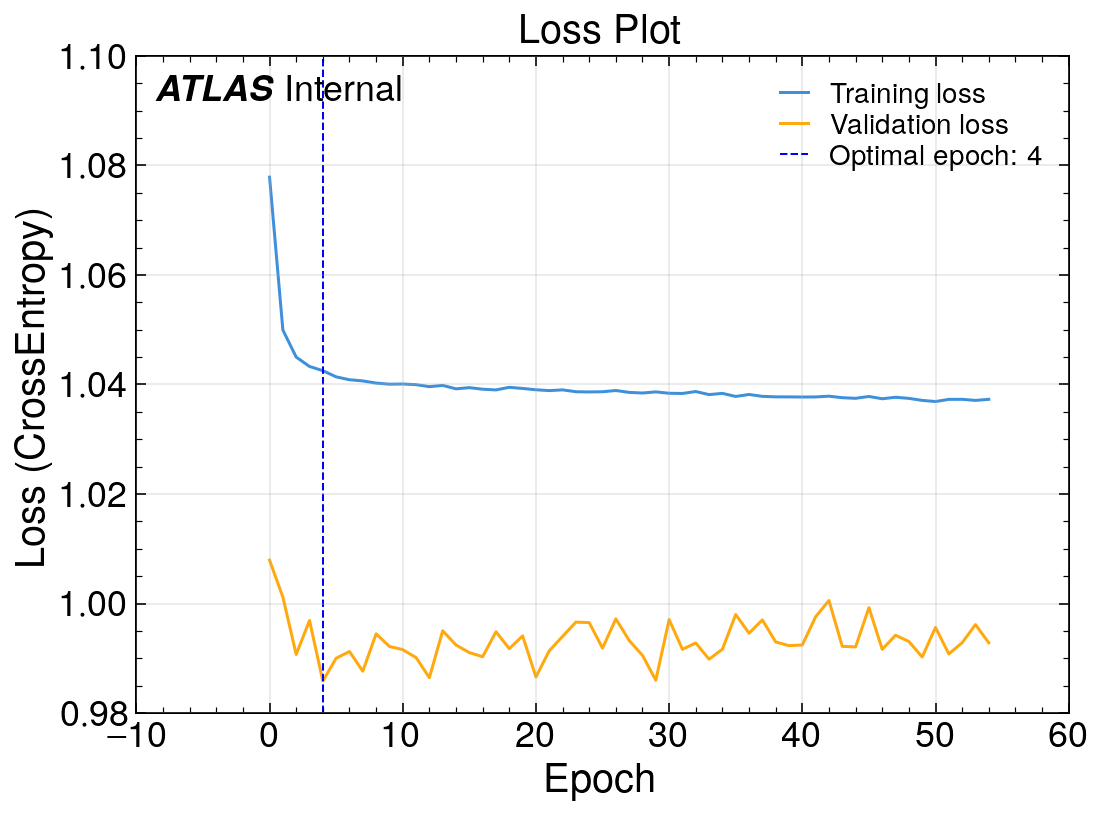

In [18]:
from src.models.plots import plot_dnn_training_curves, plot_dnn_kfold_training_curves
from src.visualization.plots import save_figure

if split_strategy == "train_test":
    fig = plot_dnn_training_curves(history)
    curve_path = plots_dir / "training_curves.png"
    save_figure(fig, curve_path)
    mlflow.log_artifact(str(curve_path))
    fig.show()

elif split_strategy == "k_fold":
    fig = plot_dnn_kfold_training_curves(fold_histories)
    curve_path = plots_dir / "training_curves_kfold.png"
    save_figure(fig, curve_path)
    mlflow.log_artifact(str(curve_path))
    fig.show()

## Predictions

Computing hard predictions and per-class probability scores on the test set.

In [19]:
from src.models.dnn import predict
from src.models.splits import build_predictions_frame

if split_strategy == "train_test":
    y_pred, y_proba = predict(model, X_test, scaler, device,
                              batch_size=cfg.model.batch_size)

# For k_fold, y_pred / y_proba / y_test are already set by train_kfold above

predictions_df = build_predictions_frame(y_test, y_pred, y_proba, class_names)
print(f"Predictions DataFrame: {predictions_df.shape}")
predictions_df.head()

Predictions DataFrame: (1965434, 8)


,y_true,y_pred,p_topquarks,p_wtaunu,p_ztautau,p_diboson,p_other,p_signal
0,5,5,0.002346,0.000923,0.000358,0.004624,0.011826,0.979924
1,5,5,0.002722,0.001671,0.003388,0.014124,0.003863,0.974232
2,3,3,0.104155,0.344887,0.120497,0.401857,0.019699,0.008905
3,2,2,0.039950,0.339194,0.398859,0.172195,0.027400,0.022402
4,0,0,0.466072,0.027482,0.015606,0.093108,0.372799,0.024934


## Serialization

Saving the trained model (with scaler) and the test-set predictions. The predictions parquet is consumed by the downstream evaluation step.

In [20]:
from src.models.dnn import save_model
from src.processing.io import save_dataframe

if cfg.pipeline.save_model:
    if split_strategy == "train_test":
        model_path = models_dir / "dnn.pt"
        save_model(model, scaler, model_path)
        mlflow.log_artifact(str(model_path))
    elif split_strategy == "k_fold":
        for fold_idx, (m, s) in enumerate(zip(models, scalers)):
            model_path = models_dir / f"dnn_fold{fold_idx}.pt"
            save_model(m, s, model_path)
            mlflow.log_artifact(str(model_path))

predictions_path = dataframes_dir / "dnn_predictions.parquet"
save_dataframe(predictions_df, predictions_path)
mlflow.log_artifact(str(predictions_path))

mlflow.end_run()